# Dimensionality Reduction

using numpy's `svd()` function to obtain all the principal components of the training set

In [1]:
import numpy as np

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data[:, 2:]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



In [3]:
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt.T[:, 0]
c2 = Vt.T[:, 1]

In [4]:
# projecting the training set onto the plane defined by the first two principal components
W2 = Vt.T[:, :2]
X2D = X_centered.dot(W2)

## Using scikit learn

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

`explained_variance_ratio_` variable indicates the proportion of the dataset's variance that lies along the axis of each principal component

In [6]:
pca.explained_variance_ratio_

array([0.99025066, 0.00974934])

Computing PCA without reducing Dimensionality. The, computing the minimum no. of dimensions required to preserve 95% of the training set's variance

In [7]:
pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

In [8]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

### Getting MNIST dataset

In [9]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data  # shape (70000, 784)
y = mnist.target.astype(int)  # MNIST labels as integers

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


Compressing the MNIST dataset down to 154 dimensions. Then using `inverse_transform()` method to decompress back to 784 dimensions

In [10]:
pca = PCA(n_components=154)
X_reduced = pca.fit_transform(X_train)
X_recovered = pca.inverse_transform(X_reduced)

In [11]:
import matplotlib.pyplot as plt
# Function to plot a grid of MNIST images
def plot_mnist_grid(X, y, rows=5, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            axes[i, j].imshow(X[idx].reshape(28, 28), cmap='gray')
            axes[i, j].set_title(str(y[idx]))
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()


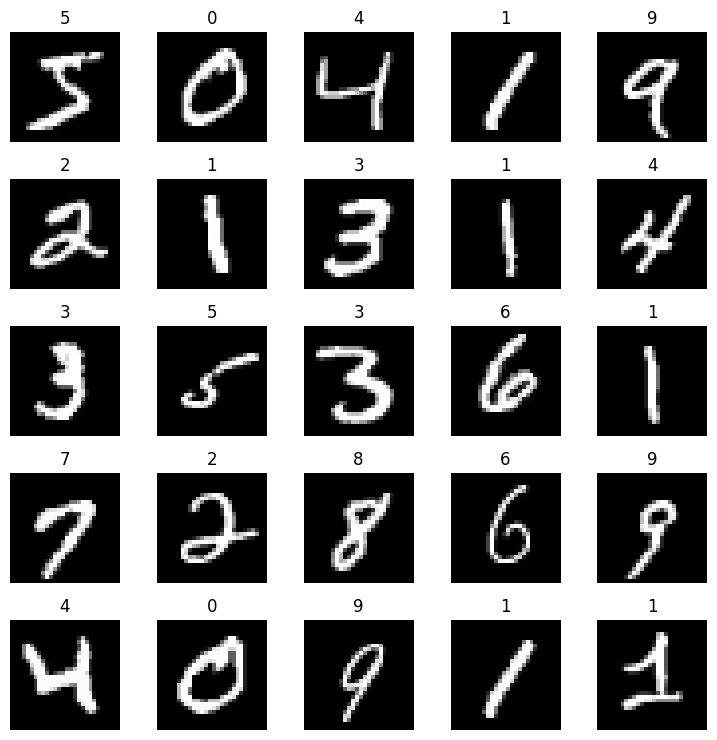

In [12]:
# Original
plot_mnist_grid(X, y, rows=5, cols=5)

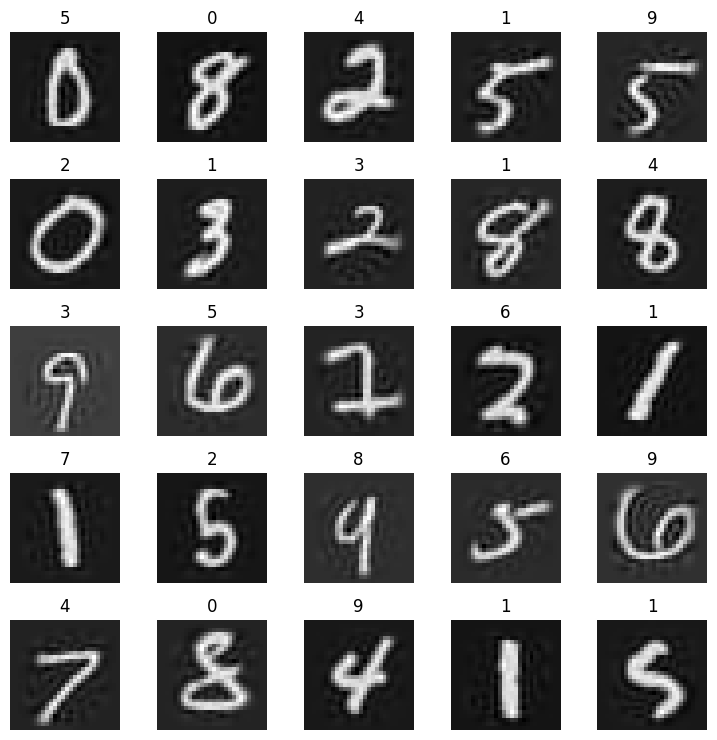

In [13]:
# Compressed
plot_mnist_grid(X_recovered, y, rows=5, cols=5)

## Randomized PCA

Setting the `svd_solver()` hyperparameter to "randomized", _Randomized PCA_ is used that quickly finds an approximation of the first _d_ principal components

In [14]:
rnd_pca = PCA(n_components=154, svd_solver="randomized")
X_reduced = rnd_pca.fit_transform(X_train)

## Incremental PCA
Incremental PCA allows us to split the training set into mini-batches and feed an IPCA algorithm one mini-batch at a time. This is useful for large training sets, as the whole training set is difficult to fit into the memory

In [15]:
# splitting MNIST dataset into 100 mini-batches using Incremental PCA
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

Alternative method using NumpPy's `memmap` class

```
X_mm = np.memmap(filename, dtype="float32", mode="readonly", shape=(m,n))
batch_size = m // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mm)
```

# Kernel PCA
Using Scikit-Learn's `KernelPCA` class to perform kPCA with an RBF kernel

1. Reduce dimensionality to two dimensions using kPCA, then using Logistic Regression for classification.
2. Use `GridSearchCV` to find the best kernel and gamma value for kPCA in order to get the best classification accuracy 

In [18]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components = 2, kernel="rbf", gamma=0.0433,
                    fit_inverse_transform=True)
X_reduced = rbf_pca.fit_transform(X)
X_preimage = rbf_pca.inverse_transform(X_reduced)

MemoryError: Unable to allocate 36.5 GiB for an array with shape (70000, 70000) and data type float64

In [17]:
from sklearn.metrics import mean_squared_error
mean_squared_error(X, X_preimage)

NameError: name 'X_preimage' is not defined

# LLE

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10)
X_reduced = lle.fit_transform(X) 